In [1]:
# 三、动手实现 softmax 回归

# 导入所需包和所需模块
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
# 定义绘图函数
def figplot(fignum=1,loss=[],acc=[]):
    plt.figure(figsize=(8,3))
    plt.suptitle('Figure '+str(fignum))
    # 打印损失值
    plt.subplot(121)
    plt.ylabel('Loss')
    plt.plot(loss[0],label='Train Loss')
    plt.plot(loss[1],label='Test Loss')
    plt.legend()
    # 打印正确率
    plt.subplot(122)
    plt.ylabel('Accuracy')
    plt.plot(acc[0],label='Train Acc')
    plt.plot(acc[1],label='Test Acc')
    plt.legend()
    # plt.grid()
    plt.show()

In [3]:
# 导入数据集
mnist_train = torchvision.datasets.FashionMNIST(root='E:\\DataSet\\FashionMNIST\\Train',
                                                train=True,
                                                download=True,
                                                transform=transforms.ToTensor())
mnist_test = torchvision.datasets.FashionMNIST(root='E:\\DataSet\\FashionMNIST\\Test',
                                               train=False,
                                               download=True,
                                               transform=transforms.ToTensor())
batch_size = 256
train_dataloader = torch.utils.data.DataLoader(mnist_train, batch_size=batch_size, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(mnist_test, batch_size=batch_size, shuffle=False)

In [4]:
# 初始化模型参数
num_inputs = 784  # 输入是28x28像素的图像
num_outputs = 10  # 十分类问题

w = torch.tensor(np.random.normal(0, 0.01, (num_inputs, num_outputs)), dtype=torch.float,
                 requires_grad=True)  # 可学习的权重参数
b = torch.zeros(num_outputs, dtype=torch.float, requires_grad=True)  # 可学习的偏差参数

In [5]:
# 构建softmax
def softmax(x):
    m = x.exp().sum(dim=1, keepdim=True)  # 矩阵同行元素求和
    return x.exp() / m  # 相除

# 模型定义
def model(x):
    return softmax(torch.mm(x.view((-1, num_inputs)), w) + b)

# 定义交叉熵损失函数
def myCrossEntropy(y_pred, y):
    return - torch.log(y_pred.gather(1, y.view(-1, 1)))

# 定义优化函数
def mySGD(params, lr, batchsize):
    for param in params:
        param.data -= lr * param.grad / batchsize

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10720\2339518976.py:44: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  print('Epoch: %d \tTrain_loss:%.5f  Train_acc: %.3f\tTest_loss:%.5f  Test_acc: %.3f\tTraining Time: %.3f seconds' % (


Epoch: 1 	Train_loss:49057.21875  Train_acc: 0.738	Test_loss:5700.26134  Test_acc: 0.758	Training Time: 14.804 seconds
Epoch: 2 	Train_loss:33999.35547  Train_acc: 0.810	Test_loss:5376.86710  Test_acc: 0.784	Training Time: 28.287 seconds
Epoch: 3 	Train_loss:31212.33594  Train_acc: 0.823	Test_loss:5097.90245  Test_acc: 0.786	Training Time: 42.801 seconds
Epoch: 4 	Train_loss:29579.43164  Train_acc: 0.831	Test_loss:5610.37155  Test_acc: 0.772	Training Time: 55.935 seconds
Epoch: 5 	Train_loss:28904.98047  Train_acc: 0.836	Test_loss:5023.09284  Test_acc: 0.792	Training Time: 68.805 seconds
Epoch: 6 	Train_loss:28194.91016  Train_acc: 0.840	Test_loss:4749.55350  Test_acc: 0.809	Training Time: 81.605 seconds
Epoch: 7 	Train_loss:27850.83398  Train_acc: 0.841	Test_loss:4803.95881  Test_acc: 0.804	Training Time: 94.556 seconds
Epoch: 8 	Train_loss:27439.81445  Train_acc: 0.842	Test_loss:4763.66518  Test_acc: 0.804	Training Time: 107.314 seconds
Epoch: 9 	Train_loss:27244.10547  Train_acc: 0.

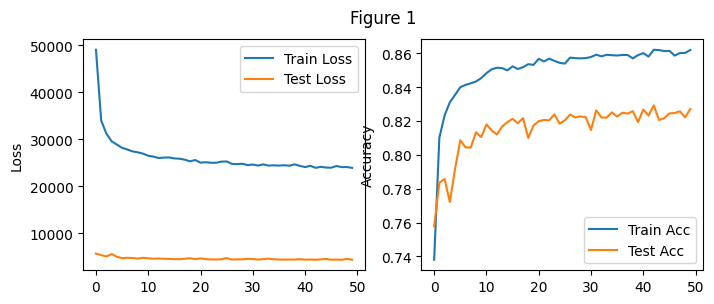

Total Time: 724.6616704463959


In [6]:
lr = 0.2  # 学习率
epochs = 50  # 训练轮数

criterion = myCrossEntropy
train_all_loss = []  # 用于存储训练集上所有的loss值
test_all_loss = []
train_acc_all = []  # 用于记录训练集上每一轮的正确率
test_acc_all = []
max_acc = 0

# 训练模型
begin = time.time()

for epoch in range(epochs):
    each_loss, train_acc_num = 0, 0
    for data, labels in train_dataloader:
        pred = model(data)
        train_loss = criterion(pred, labels).sum()
        each_loss += train_loss
        train_loss.backward()  # 反向传播
        mySGD([w, b], lr, batch_size)  # 使用小批量随机梯度下降迭代模型参数
        # 梯度清零
        pred = torch.max(pred, dim=1)[1]
        w.grad.data.zero_()
        b.grad.data.zero_()
        train_acc_num += (pred == labels).sum().item()  # 计算正确率
    train_acc_all.append(train_acc_num / mnist_train.__len__())
    train_all_loss.append(each_loss.item())

    # 在测试集上进行验证
    with torch.no_grad():
        test_loss = 0
        test_acc_num = 0
        for data, labels in test_dataloader:
            pred = model(data)
            loss = criterion(pred, labels).sum()
            test_loss += loss.item()
            labels_pred = torch.tensor(np.where(pred > 0.5, 1, 0), dtype=torch.float32)
            labels_pred = torch.max(labels_pred, dim=1)[1]
            test_acc_num += (labels_pred == labels).sum(0).item()
        test_all_loss.append(test_loss)
        test_acc_all.append(test_acc_num / mnist_test.__len__())

    print('Epoch: %d \tTrain_loss:%.5f  Train_acc: %.3f\tTest_loss:%.5f  Test_acc: %.3f\tTraining Time: %.3f seconds' % (
        epoch + 1, each_loss, train_acc_num / mnist_train.__len__(), test_loss,
        test_acc_num / mnist_test.__len__(), time.time()-begin))
end = time.time()
# 结果可视化
figplot(fignum=1,loss=[train_all_loss,test_all_loss],acc=[train_acc_all,test_acc_all])
print(f'Total Time: {end-begin}')
